--- Gerando Gráfico Comparativo Final (IDs no final das linhas) ---
Gráfico salvo em: E:\Projetos\ABMS-WP\figuras\figura_10_comparacao_cenarios_id_final.pdf


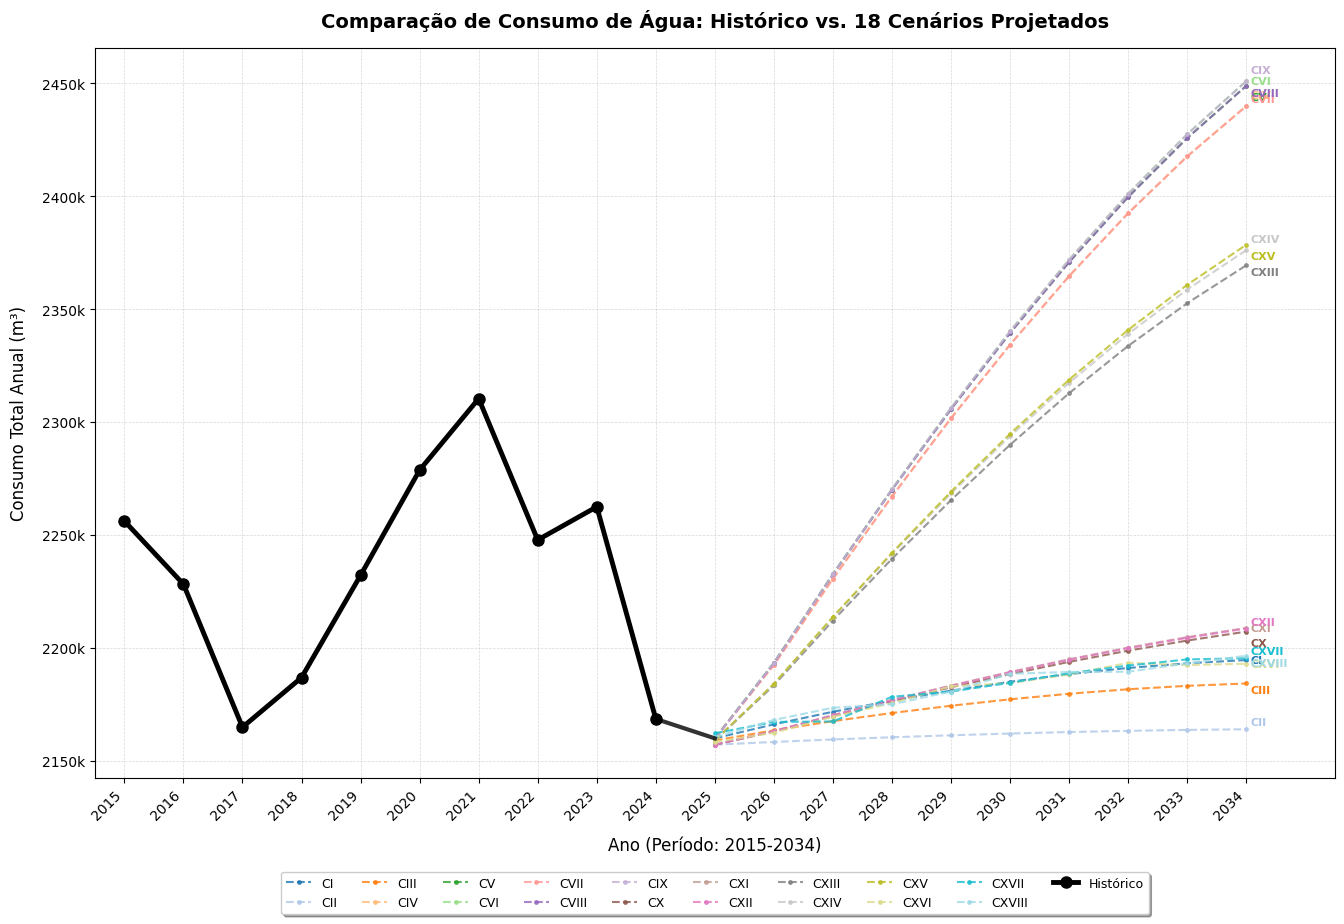

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os

# ==========================================
# 1. Configurações
# ==========================================

# Define the base project directory
# Uncomment the appropriate path for your environment
BASE_PATH = 'E:\\Projetos\\ABM-WP' # Currently active path

# Arquivos
SCENARIO_FILE = 'consumo_previsto_todos_cenarios.csv'
HISTORICAL_FILE = 'Tabela_consumo_Itapua_120m_por_mes.csv'
OUTPUT_FIG = 'figura_10_comparacao_cenarios_id_final.pdf'

# Diretórios
INPUT_DIR_RES = os.path.join(BASE_PATH, 'resultados')
INPUT_DIR_INC = os.path.join(BASE_PATH, 'includes')
OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')

def sum_yearly(df, date_col, value_cols):
    """ Agrega dados mensais para anuais """
    df_year = df.copy()
    df_year['Year'] = df_year[date_col].dt.year
    return df_year.groupby('Year')[value_cols].sum().reset_index()

def main():
    print("--- Gerando Gráfico Comparativo Final (IDs no final das linhas) ---")

    # ==========================================
    # 2. Carregar Dados
    # ==========================================
    
    # A. Cenários
    path_scenarios = os.path.join(INPUT_DIR_RES, SCENARIO_FILE)
    if not os.path.exists(path_scenarios): 
        path_scenarios = os.path.join(INPUT_DIR_INC, SCENARIO_FILE)
        
    df_scenarios = pd.read_csv(path_scenarios, sep=';', decimal=',')
    
    # Construção de Data
    if 'Mes' in df_scenarios.columns and 'Ano' in df_scenarios.columns:
        df_scenarios['Date'] = pd.to_datetime(df_scenarios['Ano'].astype(str) + '-' + df_scenarios['Mes'].astype(str) + '-01')
    elif 'Mes_Ano' in df_scenarios.columns:
        df_scenarios['Date'] = pd.to_datetime(df_scenarios['Mes_Ano'], format='%m/%Y')
    
    # Identificar Colunas de Cenários
    date_cols = ['Mes', 'Ano', 'Mes_Ano', 'Date']
    scenario_cols = [c for c in df_scenarios.columns if c not in date_cols]
    
    # Filtrar até 2035
    df_scenarios = df_scenarios[df_scenarios['Date'] < pd.to_datetime('2035-01-01')]

    # B. Histórico
    path_history = os.path.join(INPUT_DIR_INC, HISTORICAL_FILE)
    df_historical = pd.read_csv(path_history, sep=';')
    df_historical['Date'] = pd.to_datetime(df_historical['data'])
    df_historical.rename(columns={'consumo': 'Historical Consumption'}, inplace=True)

    # ==========================================
    # 3. Agregação Anual
    # ==========================================
    
    df_hist_sum = sum_yearly(df_historical, 'Date', ['Historical Consumption'])
    df_scen_sum = sum_yearly(df_scenarios, 'Date', scenario_cols)

    # ==========================================
    # 4. Plotagem
    # ==========================================
    
    fig, ax = plt.subplots(figsize=(16, 10)) 

    # --- A. Linha de Conexão (Bridge) 2024 -> 2025 ---
    last_hist_year = df_hist_sum['Year'].max()
    last_hist_val = df_hist_sum.loc[df_hist_sum['Year'] == last_hist_year, 'Historical Consumption'].values[0]
    
    first_scen_year = df_scen_sum['Year'].min()
    # Usa o Cenário Base (CI) como âncora, ou média se não existir
    if 'CI_Pop_Uniforme' in df_scen_sum.columns:
        first_scen_val = df_scen_sum.loc[df_scen_sum['Year'] == first_scen_year, 'CI_Pop_Uniforme'].values[0]
    else:
        first_scen_val = df_scen_sum.loc[df_scen_sum['Year'] == first_scen_year, scenario_cols].mean(axis=1).values[0]

    # Desenha a linha preta conectando
    ax.plot([last_hist_year, first_scen_year], [last_hist_val, first_scen_val], 
            color='black', linestyle='-', linewidth=3.0, zorder=9, alpha=0.8)

    # --- B. Plotar Cenários ---
    colors = plt.cm.tab20(np.linspace(0, 1, len(scenario_cols)))
    
    # Ciclo de offsets verticais para evitar que os IDs se atropelem no final
    # (0,0), um pouco pra cima (0, 3), um pouco pra baixo (0, -3), etc.
    offset_cycle = [(3, 0), (3, 5), (3, -5), (3, 8), (3, -8)]
    
    for idx, col in enumerate(scenario_cols):
        scenario_id = col.split('_')[0]
        
        # Plotar linha
        ax.plot(df_scen_sum['Year'], df_scen_sum[col], 
                label=scenario_id, 
                color=colors[idx], 
                linestyle='--', 
                linewidth=1.5, 
                alpha=0.8, 
                marker='.',
                markersize=5)
        
        # --- RÓTULO APENAS NO FINAL ---
        # Pegar o último ponto
        last_year = df_scen_sum['Year'].iloc[-1]
        last_val = df_scen_sum[col].iloc[-1]
        
        # Escolher offset para não sobrepor
        current_offset = offset_cycle[idx % len(offset_cycle)]
        
        ax.annotate(scenario_id, 
                    (last_year, last_val), 
                    xytext=current_offset, 
                    textcoords="offset points", 
                    ha='left', 
                    va='center',
                    fontsize=8, 
                    color=colors[idx], 
                    fontweight='bold')

    # --- C. Plotar Histórico ---
    hist_period = f"{df_hist_sum['Year'].min()}-{df_hist_sum['Year'].max()}"
    ax.plot(df_hist_sum['Year'], df_hist_sum['Historical Consumption'], 
            label='Histórico', 
            color='black', 
            linestyle='-', 
            linewidth=3.5, 
            marker='o', 
            markersize=8,
            zorder=10)

    # ==========================================
    # 5. Formatação Final
    # ==========================================
    
    full_period = f"{df_hist_sum['Year'].min()}-{df_scen_sum['Year'].max()}"
    ax.set_xlabel(f"Ano (Período: {full_period})", fontsize=12, labelpad=10)
    ax.set_ylabel('Consumo Total Anual (m³)', fontsize=12, labelpad=10)
    ax.set_title('Comparação de Consumo de Água: Histórico vs. 18 Cenários Projetados', 
                 fontsize=14, pad=15, fontweight='bold')

    # Eixos
    all_years = sorted(list(set(df_hist_sum['Year']).union(set(df_scen_sum['Year']))))
    ax.set_xticks(all_years)
    ax.set_xticklabels(all_years, rotation=45, ha='right', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}k'))
    
    # Ajustar limite X para caber os textos à direita
    max_year = df_scen_sum['Year'].max()
    ax.set_xlim(df_hist_sum['Year'].min() - 0.5, max_year + 1.5) # +1.5 ano de espaço extra
    
    plt.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.5)

    # Legenda Rodapé
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
               fancybox=True, shadow=True, ncol=10, fontsize=9)

    plt.subplots_adjust(bottom=0.15)

    # ==========================================
    # 6. Salvar
    # ==========================================
    
    if not os.path.exists(OUTPUT_DIR):
        os.makedirs(OUTPUT_DIR)

    full_output_path = os.path.join(OUTPUT_DIR, OUTPUT_FIG)
    
    plt.savefig(full_output_path, format='pdf', bbox_inches='tight')
    
    print(f"Gráfico salvo em: {full_output_path}")
    plt.show()

if __name__ == "__main__":
    main()